This script investigates the variation in the free parameters that gives a certain L2 error over a set of equilibria

In [13]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import importlib.util
import sys
from pathlib import Path
from scipy.interpolate import interp1d

# Global parameters
equil_num = 10
err_frac = 0.5
perc_success = 0.8
bc_type = "neumann"

# Scan parameters
N = 3 # size of each free parameter array
alpha_crits = np.logspace(-1, 1, N)
C_KBMs = np.logspace(-1, 1, N)
De_chie_etgs = np.logspace(-1, 1, N)
nFC_x0s = np.logspace(14, 18, N)
ncx_x0_ratios = np.logspace(0.1,1.25,N)
psi_val = 0.85
x_res = 20

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox

# Output data and files
ROOT = Path.cwd().parent.parent # /Users/nelsonlab/codes/saarelma-conner-ped
INPUT_DIR = ROOT / "src" / "inputs" / "PT_Hmode"
scan_success_dir = Path('scan_results_PTHmode_10')
verbose = False

In [ ]:
# Solver parameters
SOLVE_KW = dict(
    x_res=x_res,
    fe_degree=2,
    use_picard=False,
    picard_tol=1e-4,
    max_picard=100,
    relax=0.5,
    initial_guess="tanh",
    ne_inner_bc=bc_type,   # Saarelma A7 default; see dirichlet comparison below
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    linearize=False, # use full nonlinear form of equation
    verbose=False,
)

In [3]:
sys.path.insert(0, str(ROOT))

# `solver-firedrake.py` has a hyphen — load by file path.
_fd_spec = importlib.util.spec_from_file_location(
    "solver_firedrake",
    ROOT / "src" / "solver-firedrake.py",
)
_fd_mod = importlib.util.module_from_spec(_fd_spec)
_fd_spec.loader.exec_module(_fd_mod)
saarelma_connor_firedrake = _fd_mod.saarelma_connor_firedrake

# Add some more files
success_fp = Path('success_PTHmode.txt')
failure_fp = Path('failure_PTHmode.txt')
error_messages_fp = Path('error_messages_PTHmode.txt')


firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [4]:
# Load in all equilibria
inputs_dir = ROOT / 'src' / 'inputs' / 'PT_Hmode'

g_files = sorted(inputs_dir.glob('g*'))
p_files = sorted(inputs_dir.glob('p*'))

# Match g and p files by their shared suffix (everything after the leading 'g'/'p').
g_by_suffix = {f.name[1:]: f for f in g_files}
p_by_suffix = {f.name[1:]: f for f in p_files}
shared_suffixes = sorted(set(g_by_suffix) & set(p_by_suffix))

equilibria = [(str(g_by_suffix[s]), str(p_by_suffix[s])) for s in shared_suffixes] # all g and p files in the input folder

In [5]:
# Run scan: outer loop over equilibria (g/p pairs). Within each equilibrium we
# build ONE base_model and reuse it across all parameter combinations via
# update_free_params (cheap), instead of constructing a new model per combo.
# For each parameter combo we recompute the valid range of psi_N_inner_boundary
# from the slope-zero inner limit to the nFC/nCX-threshold outer limit, then
# sample n_psi_inner_pts boundaries within that range.
n_iter = 0
for eq_idx, (mhd_fp, kprof_fp) in enumerate(equilibria):

    eq_tag = Path(mhd_fp).name[1:]  # e.g. "150840.03000"
    eq_dir = scan_success_dir / eq_tag
    eq_dir.mkdir(parents=True, exist_ok=True)

    eq_success_fp = eq_dir / success_fp
    eq_failure_fp = eq_dir / failure_fp
    eq_error_fp = eq_dir / error_messages_fp

    # Clear outputs from any previous scan for this equilibrium.
    for old in eq_dir.glob('ne_*.npy'):
        old.unlink()
    for fp in (eq_success_fp, eq_failure_fp, eq_error_fp):
        fp.unlink(missing_ok=True)
    with open(eq_success_fp, "w") as f:
        f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, L2_error\n")
    with open(eq_failure_fp, "w") as f:
        f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner\n")
    with open(eq_error_fp, "w") as f:
        f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, message\n")

    # # Clear any prior runs for this equilibrium so re-running this cell yields
    # # a clean dataset.
    # for old in eq_dir.glob('ne_*.npy'):
    #     os.remove(old)

    print(f"\n=== Equilibrium {eq_idx + 1}/{len(equilibria)}: {eq_tag} ===")

    # Build the base model ONCE per equilibrium — the expensive flux-surface
    # averaging and equilibrium loading runs here only, not inside the loop.

    base_model = saarelma_connor_firedrake(
        P_tot_e      = P_tot_e,
        alpha_crit   = round(float(alpha_crits[0]), 3),
        C_KBM        = round(float(C_KBMs[0]), 3),
        De_chie_etg  = round(float(De_chie_etgs[0]), 3),
        nFC_x0       = round(float(nFC_x0s[0]), 3),
        ncx_x0_ratio = round(float(ncx_x0_ratios[0]), 3),
        mhd_fp       = mhd_fp,
        kprof_fp     = kprof_fp,
        verbose      = verbose,
    )
    print(f"  Base model built for {eq_tag} — starting parameter scan.")
    i=0
    for alpha_crit in alpha_crits:
        j=0
        for C_KBM in C_KBMs:
            k=0
            for De_chie_etg in De_chie_etgs:
                l=0
                for nFC_x0 in nFC_x0s:
                    for ncx_x0_ratio in ncx_x0_ratios:
                        ac = round(float(alpha_crit), 3)
                        ck = round(float(C_KBM), 3)
                        de = round(float(De_chie_etg), 3)
                        nf = round(float(nFC_x0), 3)
                        nc = round(float(ncx_x0_ratio), 3)
                        try:
                                base_model.update_free_params(
                                        alpha_crit            = ac,
                                        C_KBM                 = ck,
                                        De_chie_etg           = de,
                                        nFC_x0                = nf,
                                        ncx_x0_ratio          = nc,
                                        psi_N_inner_boundary  = psi_val,
                                )
                                x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_firedrake(**SOLVE_KW)
                                sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
                        except Exception as e:  # run fails
                            with open(eq_failure_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}\n")
                            with open(eq_error_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {e}\n")
                        else:  # run works
                            # Calculate L2 error between predicted and pfile
                            ne_pfile = interp1d(base_model.x_init, base_model.n_e_pres, kind='linear', bounds_error=False, fill_value='extrapolate')(x_sol)
                            L2_error = np.linalg.norm(ne_sol - ne_pfile) / np.linalg.norm(ne_pfile) # normalized L2 error
                            with open(eq_success_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {L2_error}\n")
                            np.save(eq_dir / f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}", sol, allow_pickle=True)
        i+=1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits for equilibrium {eq_tag}")
    del base_model # Drop the per-equilibrium base model before moving to the next one.


=== Equilibrium 1/10: 150840.03000 ===
  Base model built for 150840.03000 — starting parameter scan.
Completed 1 of 3 alpha_crits for equilibrium 150840.03000
Completed 2 of 3 alpha_crits for equilibrium 150840.03000
Completed 3 of 3 alpha_crits for equilibrium 150840.03000

=== Equilibrium 2/10: 152960.03500 ===
  Base model built for 152960.03500 — starting parameter scan.
Completed 1 of 3 alpha_crits for equilibrium 152960.03500
Completed 2 of 3 alpha_crits for equilibrium 152960.03500
Completed 3 of 3 alpha_crits for equilibrium 152960.03500

=== Equilibrium 3/10: 153100.03000 ===
  Base model built for 153100.03000 — starting parameter scan.
Completed 1 of 3 alpha_crits for equilibrium 153100.03000
Completed 2 of 3 alpha_crits for equilibrium 153100.03000
Completed 3 of 3 alpha_crits for equilibrium 153100.03000

=== Equilibrium 4/10: 153140.04750 ===
  Base model built for 153140.04750 — starting parameter scan.
Completed 1 of 3 alpha_crits for equilibrium 153140.04750
Complete

Plotting and analysis

In [10]:
# Load successful runs with normalized L2 (err_frac) below the threshold set in cell 1.
import csv


def ne_npy_path(eq_dir, ac, ck, de, nf, nc, psi_val):
    """Match filename convention used in the scan cell."""
    return eq_dir / f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}.npy"


# filtered_runs[eq_tag] -> list of run dicts passing the err_frac cut
filtered_runs = {}
# flat list of all kept runs (same dicts as above)
good_runs_all = []

n_success_total = 0
n_kept_total = 0

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    eq_dir = scan_success_dir / eq_tag
    success_path = eq_dir / success_fp.name
    if not success_path.exists():
        print(f"[skip] no success log for {eq_tag}")
        continue

    eq_runs = []
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header
        for row in reader:
            if len(row) < 8:
                continue
            n_success_total += 1
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = float(ac), float(ck), float(de), float(nf), float(nc)
            psi_b = float(psi_b)
            l2 = float(l2)

            if l2 >= err_frac:
                continue

            npy_path = ne_npy_path(eq_dir, ac, ck, de, nf, nc, psi_b)
            if not npy_path.exists():
                continue

            sol = np.load(npy_path, allow_pickle=True).item()
            run = dict(
                eq_tag=eq_tag,
                mhd_fp=mhd_fp,
                kprof_fp=kprof_fp,
                alpha_crit=ac,
                C_KBM=ck,
                De_chie_etg=de,
                nFC_x0=nf,
                ncx_x0_ratio=nc,
                psi_N_inner=psi_b,
                norm_L2_error=l2,
                x=np.asarray(sol["x"], dtype=float),
                ne=np.asarray(sol["y"], dtype=float),
                nFC=np.asarray(sol.get("nFC", []), dtype=float),
                nCX=np.asarray(sol.get("nCX", []), dtype=float),
                npy_path=str(npy_path),
            )
            eq_runs.append(run)
            good_runs_all.append(run)
            n_kept_total += 1

    if eq_runs:
        filtered_runs[eq_tag] = eq_runs

print(f"Loaded {n_kept_total} / {n_success_total} successful runs "
      f"with err_frac < {err_frac:g}")
print(f"Equilibria with at least one good run: {len(filtered_runs)} / {len(equilibria)}")

Loaded 594 / 1605 successful runs with err_frac < 0.5
Equilibria with at least one good run: 10 / 10


In [11]:
# For each parameter combination, keep it if L2 < err_frac on at least
# perc_success fraction of all equilibria (from cell 1).
import csv
from collections import defaultdict

PARAM_NAMES = ("alpha_crit", "C_KBM", "De_chie_etg", "nFC_x0", "ncx_x0_ratio")


def param_key(ac, ck, de, nf, nc):
    return (round(float(ac), 3), round(float(ck), 3),
            round(float(de), 3), round(float(nf), 3), round(float(nc), 3))


# combo_stats[key] -> list of per-equilibrium outcomes for that 5D combo
combo_stats = defaultdict(list)

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp.name
    if not success_path.exists():
        continue

    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            key = param_key(ac, ck, de, nf, nc)
            l2 = float(l2)
            combo_stats[key].append(dict(
                eq_tag=eq_tag,
                norm_L2_error=l2,
                passed=l2 < err_frac,
            ))

n_equilibria_total = len(equilibria)

# filtered_combos[key] -> summary + loaded profiles for passing equilibria
filtered_combos = {}

for key, outcomes in combo_stats.items():
    n_pass = sum(1 for o in outcomes if o["passed"])
    success_fraction = n_pass / n_equilibria_total

    if success_fraction < perc_success:
        continue

    # Attach full run dicts (with profiles) from cell above where available
    runs = [
        r for r in good_runs_all
        if param_key(r["alpha_crit"], r["C_KBM"], r["De_chie_etg"],
                     r["nFC_x0"], r["ncx_x0_ratio"]) == key
    ]
    passing_eq_tags = {o["eq_tag"] for o in outcomes if o["passed"]}

    filtered_combos[key] = dict(
        params=dict(zip(PARAM_NAMES, key)),
        n_equilibria_passing=n_pass,
        n_equilibria_total=n_equilibria_total,
        success_fraction=success_fraction,
        per_equilibrium=outcomes,
        passing_eq_tags=sorted(passing_eq_tags),
        runs=runs,
        mean_err_frac=float(np.mean([o["norm_L2_error"] for o in outcomes if o["passed"]])),
        max_err_frac=float(np.max([o["norm_L2_error"] for o in outcomes if o["passed"]])),
    )

# Parameter ranges spanned by robust combinations
param_ranges_robust = {}
if filtered_combos:
    for name in PARAM_NAMES:
        vals = [d["params"][name] for d in filtered_combos.values()]
        param_ranges_robust[name] = (min(vals), max(vals))

print(f"Kept {len(filtered_combos)} / {len(combo_stats)} parameter combinations "
      f"with success_fraction >= {perc_success:g} "
      f"({perc_success * 100:.0f}% of {n_equilibria_total} equilibria)")
if param_ranges_robust:
    print(f"Parameter ranges over robust combinations (normalized L2 error < {err_frac}):")
    for name, (lo, hi) in param_ranges_robust.items():
        print(f"  {name}: [{lo:g}, {hi:g}]")
else:
    print("No combinations met the perc_success threshold — try lowering perc_success or err_frac.")

Kept 8 / 222 parameter combinations with success_fraction >= 0.8 (80% of 10 equilibria)
Parameter ranges over robust combinations (normalized L2 error < 0.5):
  alpha_crit: [0.1, 0.1]
  C_KBM: [0.1, 10]
  De_chie_etg: [0.1, 10]
  nFC_x0: [1e+16, 1e+18]
  ncx_x0_ratio: [1.259, 17.783]


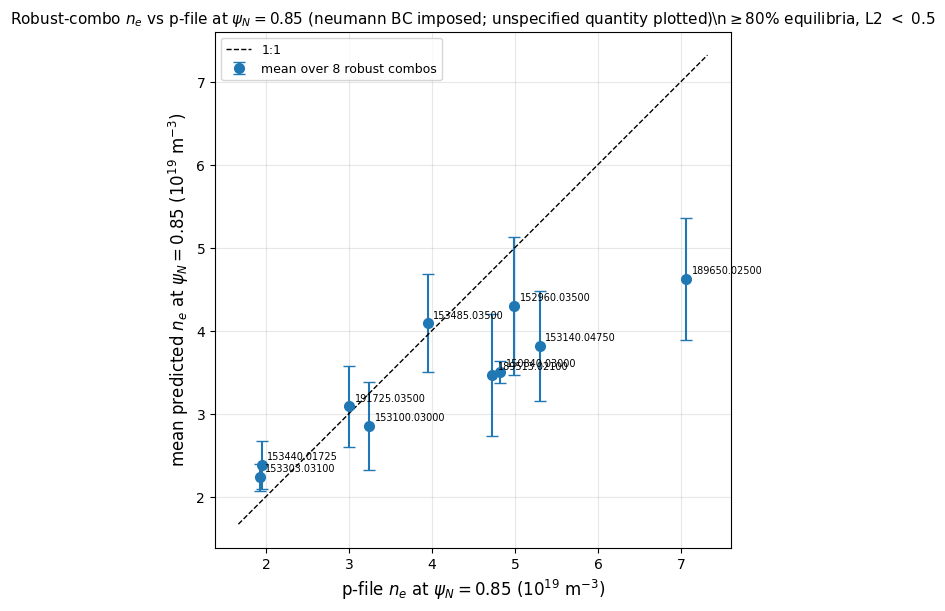

Plotted 10 / 10 equilibria using 8 robust combinations (quantity: ne)


In [ ]:
# Compare p-file vs mean model prediction at psi_N_plot for every equilibrium.
# Plot the *unspecified* inner BC quantity:
#   bc_type == "neumann"  -> n_e emerges      -> compare n_e
#   bc_type == "dirichlet" -> dne/dx emerges -> compare dn_e/dx
# Requires cells 7–8 (filtered_combos, good_runs_all).

psi_N_plot = 0.85  # psi_N at which to sample


def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20


def value_at_psi(x_grid, y_grid, x_at_psi):
    return float(interp1d(
        x_grid, y_grid, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(x_at_psi))


if bc_type == "neumann":
    plot_quantity = "ne"
elif bc_type == "dirichlet":
    plot_quantity = "dne_dx"
else:
    raise ValueError(f"bc_type must be 'neumann' or 'dirichlet', got {bc_type!r}")

if not filtered_combos:
    print("No robust combinations in filtered_combos — run cells 7–8 first.")
else:
    pfile_pts = []
    pred_mean_pts = []
    pred_std_pts = []
    eq_labels = []
    skipped = []

    for mhd_fp, kprof_fp in equilibria:
        eq_tag = Path(mhd_fp).name[1:]

        ref = saarelma_connor_firedrake(
            P_tot_e=P_tot_e,
            alpha_crit=round(float(alpha_crits[0]), 3),
            C_KBM=round(float(C_KBMs[0]), 3),
            De_chie_etg=round(float(De_chie_etgs[0]), 3),
            nFC_x0=round(float(nFC_x0s[0]), 3),
            ncx_x0_ratio=round(float(ncx_x0_ratios[0]), 3),
            mhd_fp=mhd_fp,
            kprof_fp=kprof_fp,
            verbose=False,
        )
        ref.setup_solver_grids(res=x_res)
        psi_to_x = interp1d(
            ref.psi_N_pres, ref.x_init,
            kind="linear", bounds_error=False, fill_value="extrapolate",
        )
        x_at_psi = float(psi_to_x(psi_N_plot))

        if plot_quantity == "ne":
            psi_pfile, ne_pfile = read_pfile_ne(kprof_fp)
            pfile_val = float(interp1d(
                psi_pfile, ne_pfile, kind="linear",
                bounds_error=False, fill_value="extrapolate",
            )(psi_N_plot))
        else:
            dne_dx_pfile = np.gradient(ref.n_e_pres, ref.x_init)
            pfile_val = value_at_psi(ref.x_init, dne_dx_pfile, x_at_psi)

        pred_vals = []
        for combo in filtered_combos.values():
            run = next((r for r in combo["runs"] if r["eq_tag"] == eq_tag), None)
            if run is None:
                continue
            if plot_quantity == "ne":
                pred_vals.append(value_at_psi(run["x"], run["ne"], x_at_psi))
            else:
                dne_dx_pred = np.gradient(run["ne"], run["x"])
                pred_vals.append(value_at_psi(run["x"], dne_dx_pred, x_at_psi))

        if not pred_vals:
            skipped.append(eq_tag)
            continue

        pfile_pts.append(pfile_val)
        pred_mean_pts.append(float(np.mean(pred_vals)))
        pred_std_pts.append(float(np.std(pred_vals)))
        eq_labels.append(eq_tag)

    if not pfile_pts:
        print("No data to plot — check filtered_combos and psi_N_plot.")
        if skipped:
            print(f"Skipped equilibria (no robust-combo runs): {skipped}")
    else:
        pfile_pts = np.array(pfile_pts)
        pred_mean_pts = np.array(pred_mean_pts)
        pred_std_pts = np.array(pred_std_pts)

        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

        if plot_quantity == "ne":
            x_plot = pfile_pts / 1e19
            y_plot = pred_mean_pts / 1e19
            yerr = pred_std_pts / 1e19
            xlabel = rf"p-file $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
            ylabel = rf"mean predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
            quantity_lbl = r"$n_e$"
        else:
            x_plot = pfile_pts
            y_plot = pred_mean_pts
            yerr = pred_std_pts
            xlabel = rf"p-file $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"
            ylabel = rf"mean predicted $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"
            quantity_lbl = r"$dn_e/dx$"

        ax.errorbar(
            x_plot, y_plot, yerr=yerr,
            fmt="o", ms=7, capsize=4, lw=1.5,
            label=rf"mean over {len(filtered_combos)} robust combos",
        )

        lo = min(x_plot.min(), (y_plot - yerr).min())
        hi = max(x_plot.max(), (y_plot + yerr).max())
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, label="1:1")

        for x, y, lbl in zip(x_plot, y_plot, eq_labels):
            ax.annotate(lbl, (x, y), fontsize=7, xytext=(4, 4),
                        textcoords="offset points")

        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(
            rf"Robust-combo {quantity_lbl} vs p-file at $\psi_N={psi_N_plot}$ "
            rf"({bc_type} BC imposed; unspecified quantity plotted) \n"
            rf"$\geq${perc_success*100:.0f}% equilibria, L2 $<$ {err_frac}",
            fontsize=11,
        )
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_aspect("equal", adjustable="box")
        plt.show()

        print(
            f"Plotted {len(eq_labels)} / {len(equilibria)} equilibria "
            f"using {len(filtered_combos)} robust combinations "
            f"(quantity: {plot_quantity})"
        )
        if skipped:
            print(f"Skipped (no robust-combo run data): {skipped}")